# 2.3.1. Загрузка данных и первичный анализ

## 1.Импорт библиотек

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, PrecisionRecallDisplay

from sklearn.dummy import DummyClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.inspection import permutation_importance

import json
import joblib

## 2.Загрузка CSV

In [34]:
df = pd.read_csv('data/S06-hw-dataset-02.csv')

## 3.Анализ

### 3.1.Базовые статистики

In [57]:
print(df.head(), df.info(), df.describe(), sep = '\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

### 3.2.Распределение

In [36]:
df.target.value_counts(normalize=True)

target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

## 4.Разделение

In [37]:
X, y = df.iloc[:,1:-1], df.target

# 2.3.2. Train/Test-сплит и воспроизводимость

## 1.Разделение на train/test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 2.Пояснение
random_state необходим для одинакового разделения при каждом запуске, значение особой роли не играет. stratify необходим для разделения классов в train/test в той пропорции, в какой был исходный датасет

# Артефакты

In [39]:
all_metrics = []
search_summaries = []

# 2.3.3. Baseline’ы

In [40]:
dm = DummyClassifier(strategy="most_frequent")
dm.fit(X_train, y_train)

y_pred = dm.predict(X_test)
y_proba = dm.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
c_matrix = confusion_matrix(y_test, y_pred)

print(f'accuracy_score: {acc}\nroc_auc_score: {roc_auc}\nf1_score: {f1}\nconfusion_matrix:\n {c_matrix}')

all_metrics.append({
    'model':'DummyClassifier',
    'accuracy_score': acc,
    'roc_auc_score': roc_auc,
    'f1_score': f1,
    'confusion_matrix': c_matrix})

accuracy_score: 0.7375
roc_auc_score: 0.5
f1_score: 0.0
confusion_matrix:
 [[2655    0]
 [ 945    0]]


In [41]:
pipe = Pipeline([
    ('scaller', StandardScaler()),
    ('logreg', LogisticRegression(max_iter = 1000, random_state = 42))
    ])

param_grid = {'logreg__C': [0.01, 0.1, 1.0, 10.0 ,100.0]}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1)

grid_search.fit(X_train, y_train)

lrm = grid_search.best_estimator_

y_pred = lrm.predict(X_test)
y_proba = lrm.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
c_matrix = confusion_matrix(y_test, y_pred)

print(f'accuracy_score: {acc}\nroc_auc_score: {roc_auc}\nf1_score: {f1}\nconfusion_matrix:\n {c_matrix}')

all_metrics.append({
    'model':'LogisticRegression',
    'accuracy_score': acc,
    'roc_auc_score': roc_auc,
    'f1_score': f1,
    'confusion_matrix': c_matrix})

search_summaries.append({
    'model':'LogisticRegression',
    'best_C': grid_search.best_params_['logreg__C'],
    'best_cv_score': float(grid_search.best_score_) })

accuracy_score: 0.8119444444444445
roc_auc_score: 0.7976938789744817
f1_score: 0.5606748864373783
confusion_matrix:
 [[2491  164]
 [ 513  432]]


# 2.3.4. Модели недели 6

## 1.Дерево

In [42]:
tfm = DecisionTreeClassifier(random_state = 42)
tfm.fit(X_train, y_train)

path = tfm.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas = np.unique(ccp_alphas)
ccp_alphas = ccp_alphas[:: max(1,int(0.1*(len(ccp_alphas))))]

best_cv_score = -1.0
best_alpha = None
best_model = None
            
for a in ccp_alphas:
    m = DecisionTreeClassifier(random_state=42, ccp_alpha=float(a))
    
    cv_scores = cross_val_score(m, X_train, y_train, cv=5, scoring='roc_auc')
    mean_cv_score = cv_scores.mean()
    
    if mean_cv_score > best_cv_score:
        best_cv_score = mean_cv_score
        best_alpha = float(a)
        m.fit(X_train, y_train)
        best_model = m

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
c_matrix = confusion_matrix(y_test, y_pred)
node_count = best_model.tree_.node_count

print(f'accuracy_score: {accuracy}\n'
      f'roc_auc_score: {roc_auc}\n'
      f'f1_score: {f1}\n'
      f'confusion_matrix:\n{c_matrix}\n'
      f'node_count: {node_count}')

all_metrics.append({
    'model':'DecisionTreeClassifier',
    'accuracy_score':  accuracy,
    'roc_auc_score':roc_auc,
    'f1_score': f1,
    'confusion_matrix':c_matrix,
    'node_count':  node_count})

search_summaries.append({
    'model':'DecisionTreeClassifier',
    'best_ccp_alpha': best_alpha,
    'best_cv_score': best_cv_score })

accuracy_score: 0.8405555555555555
roc_auc_score: 0.8399553602566784
f1_score: 0.6631455399061033
confusion_matrix:
[[2461  194]
 [ 380  565]]
node_count: 279


## 2.Лес

In [43]:
rf_best_model = None
best_cv_score = -1.0
best_max_features = None

for mf in [0.3, 0.5, 0.7, 1.0, 'sqrt', 'log2']:
    rfm = RandomForestClassifier(
        n_estimators = 100,
        random_state = 42,
        max_features = mf,
        oob_score = True,
        n_jobs = -1
        ) 
    
    cv_scores = cross_val_score(rfm, X_train, y_train, cv=5, scoring='roc_auc')
    mean_cv_score = cv_scores.mean()
    
    if mean_cv_score>best_cv_score:
        rfm.fit(X_train, y_train)
        rf_best_model = rfm
        best_cv_score = mean_cv_score
        best_max_features = mf

y_pred = rf_best_model.predict(X_test)
y_proba = rf_best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
c_matrix = confusion_matrix(y_test, y_pred)
oob = rf_best_model.oob_score_

print(f'accuracy_score: {accuracy}\n'
      f'roc_auc_score: {roc_auc}\n'
      f'f1_score: {f1}\n'
      f'confusion_matrix:\n{c_matrix}\n'
      f'oob_score: {oob}')

all_metrics.append({
    'model':'RandomForestClassifier',
    'accuracy_score':  accuracy,
    'roc_auc_score':roc_auc,
    'f1_score': f1,
    'confusion_matrix':c_matrix,
    })

search_summaries.append({
    'model':'RandomForestClassifier',
    'best_max_features': best_max_features,
    'best_cv_score': best_cv_score })

best_model_meta = [{
    'model': 'RandomForestClassifier',
    'metrics': {
        'accuracy_score':  accuracy,
        'roc_auc_score':roc_auc,
        'f1_score': f1,
        'oob_score': oob},
    'confusion_matrix': c_matrix}]

accuracy_score: 0.8905555555555555
roc_auc_score: 0.9261519146264909
f1_score: 0.7555831265508685
confusion_matrix:
[[2597   58]
 [ 336  609]]
oob_score: 0.8901388888888889


## 3.boosting 

In [44]:
tree = DecisionTreeClassifier(random_state = 42, max_depth = 1)

ada = AdaBoostClassifier(estimator = tree,
                         n_estimators = 200,
                         learning_rate = 0.6,
                         random_state = 42
                        )

ada.fit(X_train, y_train)

y_proba = ada.predict_proba(X_test)[:,1]
y_pred =  ada.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test,y_proba)
f1 = f1_score(y_test, y_pred)
c_matrix = confusion_matrix(y_test, y_pred)

print(f'accuracy_score: {accuracy}\nroc_auc_score: {roc_auc}\nf1_score: {f1}\nconfusion_matrix:\n {c_matrix}')

all_metrics.append({
    'model':'AdaBoostClassifier',
    'accuracy_score': accuracy,
    'roc_auc_score': roc_auc,
    'f1_score': f1,
    'confusion_matrix': c_matrix})

accuracy_score: 0.8108333333333333
roc_auc_score: 0.8208549307984336
f1_score: 0.5260960334029228
confusion_matrix:
 [[2541  114]
 [ 567  378]]


# 2.3.6. Интерпретация

In [45]:
perm = permutation_importance(
    rf_best_model, X_test, y_test,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc"
)

pimp = perm.importances_mean
idx = np.argsort(pimp)[::-1][:10]
for i in idx:
    print(X.columns[i])

f16
f01
f19
f12
f07
f23
f02
f30
f08
f18


# 2.4. Артефакты эксперимента

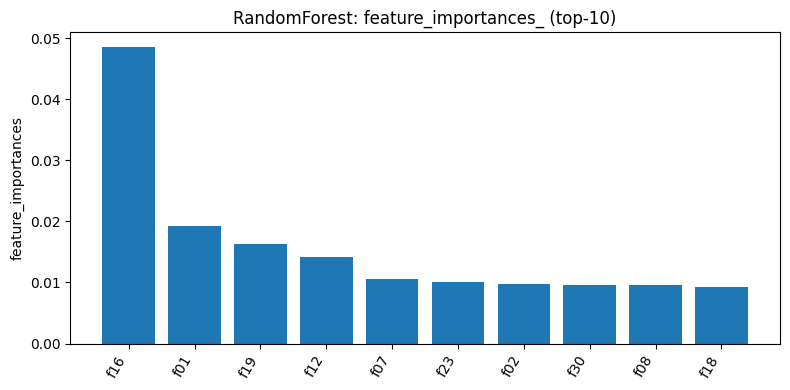

<Figure size 600x500 with 0 Axes>

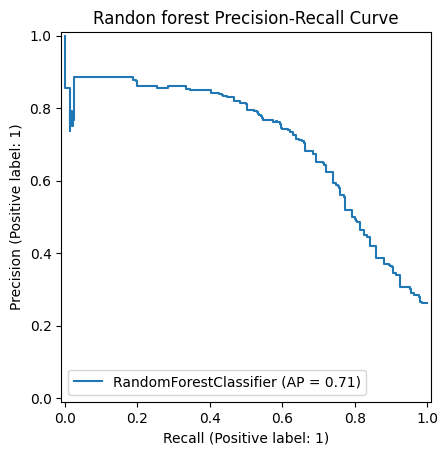

In [53]:
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(all_metrics, f, indent=4, default=str)

with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4, default=str)

joblib.dump(rf_best_model, 'artifacts/best_model.joblib')

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=4, default=str)

#гистограма с feature_importances
plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), pimp[idx])
plt.xticks(range(len(idx)), [ X.columns[i] for i in idx], rotation=60, ha="right")
plt.ylabel("feature_importances")
plt.title("RandomForest: feature_importances_ (top-10)")
plt.tight_layout()
plt.show()
plt.savefig('artifacts/figures/feature_importance.png', dpi=150)
plt.close()

y_proba = best_model.predict_proba(X_test)[:, 1]
# Строим и сохраняем PR-кривую
plt.figure(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba,
    name=type(rf_best_model).__name__
)
plt.title("Randon forest Precision-Recall Curve")
plt.savefig(
    'artifacts/figures/pr_curve.png',
    bbox_inches='tight',
    dpi=150
)